In [1]:
import sys
import os
sys.path.append(os.path.abspath("../src"))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.ticker import MultipleLocator, FuncFormatter
from resicual_fct import timing_residual

In [3]:
#given parameters 
G = 6.7e-39 #GeV^-2
chi = 1.6e35 #GeV^-1
T = 7.6e21 #GeV^-1
rho = 2.3e-42  #GeV^4
delta = 0.1
H = 1.5e-42 #GeV 
a = 1.0
deltadot = H*delta /(2*np.sqrt(np.pi))

In [4]:
#reference values index:
kref = 115
thetaref = 70  
mref = 50
tendref = 60

#transition points: 
osc = 1e-33 #at m ~ osc oscillations start
k0 = np.sqrt(12*np.pi*G*rho) #case k ~ H

#variable ranges:
m = np.unique(np.r_[np.logspace(-34.5, -31.5, 100),                #GeV
                    np.logspace(np.log10(3*osc), -31.5, 100)])      #extra points at oscillation
theta = np.linspace(0.0, np.pi, 100) 
k = np.unique(np.r_[np.logspace(np.log10(0.001*H), np.log10(0.01*m[mref]), 100), #GeV #this is k/a not k
                    np.logspace(np.log10(0.9*k0), np.log10(1.1*k0), 30)])        #extra points near k ~ H
tend = np.unique(np.r_[np.logspace(31, 34, 100),                   #GeV^-1
                       np.logspace(np.log10(1.5/osc), 34, 120)])     #extra points at oscillation

In [5]:
#reference values (green lines in plots)
print('m_1 ~ ', np.round(m[mref]*1e9*1e24, 0), 'e-24 eV')
print('theta_1 ~ ', np.round(theta[thetaref]/np.pi, 1), ' pi')
print('k_1 ~ ', np.round(k[kref]*1.56e38, 0), ' Mpc^-1')
print('tend_1 ~ ', np.round(tend[tendref]/(4.8e31), 0), ' yr')

m_1 ~  1.0 e-24 eV
theta_1 ~  0.7  pi
k_1 ~  66.0  Mpc^-1
tend_1 ~  14.0  yr


In [6]:
#usefull combinations
Theta = lambda t, theta, m: m*t + theta
preX = lambda m: 4*np.pi*G*rho*delta/m**3
preY = lambda k, m: 8*np.pi*G*rho*deltadot/(m**2*(12*np.pi*G*rho-k**2))

#deltaT
def XY(time, f, theta, m):  
    t1, t2, t3, t4 = time+a*chi, time, time+a*chi+T, time+T
    return f(2*Theta(t1, theta, m)) - f(2*Theta(t2, theta, m)) - f(2*Theta(t3, theta, m)) + f(2*Theta(t4, theta, m)) 

def deltaT(time, theta, k, m): 
    return preX(m) * XY(time, np.sin, theta, m) + preY(k, m)* XY(time, np.cos, theta, m)

#Residual
def R(tend, theta, k, m):
    innerfct = lambda t: deltaT(t, theta, k, m)/T
    tend = tend % (np.pi/m) #integration over full period = 0 -> neglegtion before integration is less expensive
    return quad(innerfct, 0.0, tend)[0]

def residual(tend, theta, k, m):
    residual_m = np.array([R(tend[tendref], theta[thetaref], k[kref], m_) for m_ in m]) /(4.8e31)
    residual_k = np.array([R(tend[tendref], theta[thetaref], k_, m[mref]) for k_ in k]) /(4.8e31)
    residual_theta = np.array([R(tend[tendref], theta_, k[kref], m[mref]) for theta_ in theta]) /(4.8e31)
    residual_tend = np.array([R(tend_, theta[thetaref], k[kref], m[mref]) for tend_ in tend]) /(4.8e31)
    return residual_m, residual_k, residual_theta, residual_tend

In [7]:
#calculation
res = residual(tend, theta, k, m) # yr

C:\Users\lucal\AppData\Local\Temp\ipykernel_15940\20406641.py:18: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(innerfct, 0.0, tend)[0]
C:\Users\lucal\AppData\Local\Temp\ipykernel_15940\20406641.py:18: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(innerfct, 0.0, tend)[0]


In [8]:
#Plotting
p_read = 1.5 #factor for fontsize of axes, ticks, legend

def plot_reflines(axes, refline, color, label):
    axes.axvline(refline, linestyle=':', color=color, label=label)
    
def plot_residual(axes, x, y, label=None, refline='None', reflinelabel=None, 
                  xscale='linear', yscale='linear', xlabel=None, ylabel=None):
    axes.plot(x, y, color='black', linestyle='None', marker='d', markeredgecolor='black', markersize=3, label=label)
    if refline!=None: plot_reflines(axes, refline, color='green', label=reflinelabel) #this ref-value is used in other plots
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.tick_params(axis='both', labelsize=8*p_read)
    plt.grid(axis='y', color='gainsboro') 
    plt.xlabel(xlabel, fontsize=10*p_read)
    plt.ylabel(ylabel, fontsize=10*p_read)
    plt.tight_layout()

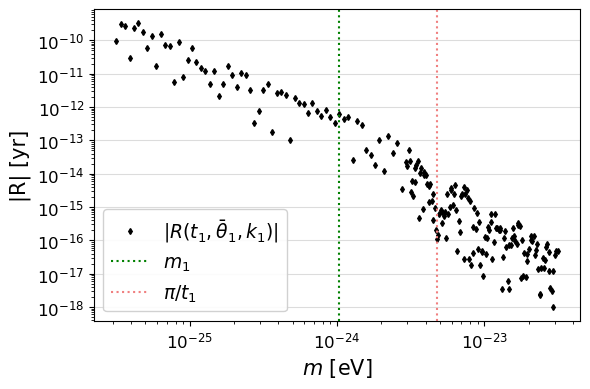

In [9]:
#plot_m_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
plot_residual(ax, m*1e9, np.abs(res[0]), label=r'$|R (t_1, \bar\theta_1, k_1)|$', refline=m[mref]*1e9, reflinelabel=r'$m_1$', 
              xscale='log', yscale='log', xlabel=r'$m$ [eV]', ylabel=r'|R| [yr]')
plot_reflines(ax, np.pi*1e9/tend[tendref], color='lightcoral', label=r'$\pi/t_1$')
ax.legend(fontsize=9*p_read, framealpha=0.9)
#plt.savefig('R_m_dependence.png', dpi=300, bbox_inches="tight")
plt.show()

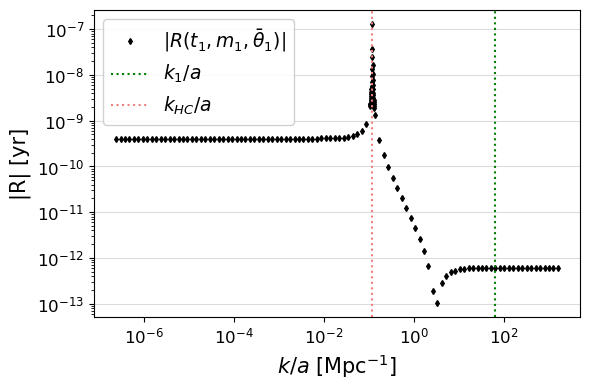

In [10]:
#plot_k_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
plot_residual(ax, k*1.56e38, np.abs(res[1]), label=r'$|R (t_1, m_1, \bar\theta_1)|$', refline=k[kref]*1.56e38, reflinelabel=r'$k_1/a$', 
              xscale='log', yscale='log', xlabel=r'$k/a$ [Mpc$^{-1}$]', ylabel=r'|R| [yr]')
plot_reflines(ax, k0*1.56e38, color='lightcoral', label='$k_{HC}/a$')
ax.legend(fontsize=9*p_read, framealpha=0.9)
#plt.savefig('R_k_dependence.png', dpi=300, bbox_inches="tight")
plt.show()

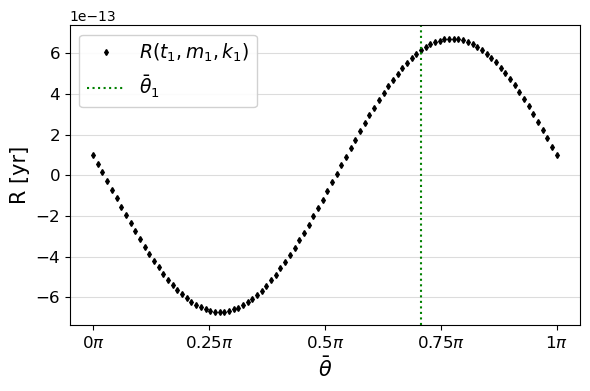

In [11]:
#plot_theta_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
plot_residual(ax, theta, res[2], label=r'$R (t_1, m_1, k_1)$', refline=theta[thetaref], reflinelabel=r'$\bar\theta_1$', 
              xlabel=r'$\bar\theta$', ylabel=r'R [yr]')
ax.xaxis.set_major_locator(MultipleLocator(np.pi/4))  #change x-axis ticks to multiples of pi/4          
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: rf"${x/np.pi:.2g}\pi$"))
ax.legend(fontsize=9*p_read, framealpha=0.9)
#plt.savefig('R_theta_dependence.png', dpi=300, bbox_inches="tight")
plt.show()

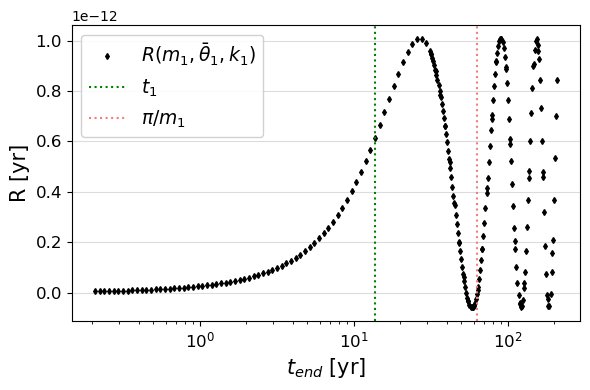

In [12]:
#plot_tend_dependence
fig, ax = plt.subplots(figsize=(6, 4)) 
plot_residual(ax, tend/(4.8e31), res[3], label=r'$R (m_1, \bar\theta_1, k_1)$', refline=tend[tendref]/(4.8e31), reflinelabel=r'$t_1$', 
              xscale = 'log', xlabel=r'$t_{end}$ [yr]', ylabel=r'R [yr]')
plot_reflines(ax, np.pi/(m[mref]*4.8e31), color='lightcoral', label=r'$\pi/m_1$')
ax.legend(fontsize=9*p_read, framealpha=0.9)
#plt.savefig('R_tend_dependence.png', dpi=300, bbox_inches="tight")
plt.show()